大自然的 Target (真实黎曼零点归一化间距) 已锁定：
[0.4466477  0.6081849  0.63390154 0.84157217 1.0073023  1.1745535
 1.1813623  1.3672106  1.7392645 ]

🚀 启动 AI 逆向工程：开始用真实零点反推时间演化参数...
Epoch  30 | Loss: 0.0260 | 探索到的物理参数 theta: 0.2189
Epoch  60 | Loss: 0.0646 | 探索到的物理参数 theta: 0.1761
Epoch  90 | Loss: 0.0229 | 探索到的物理参数 theta: 0.1981
Epoch 120 | Loss: 0.1472 | 探索到的物理参数 theta: 0.1865
Epoch 150 | Loss: 0.1227 | 探索到的物理参数 theta: 0.2204


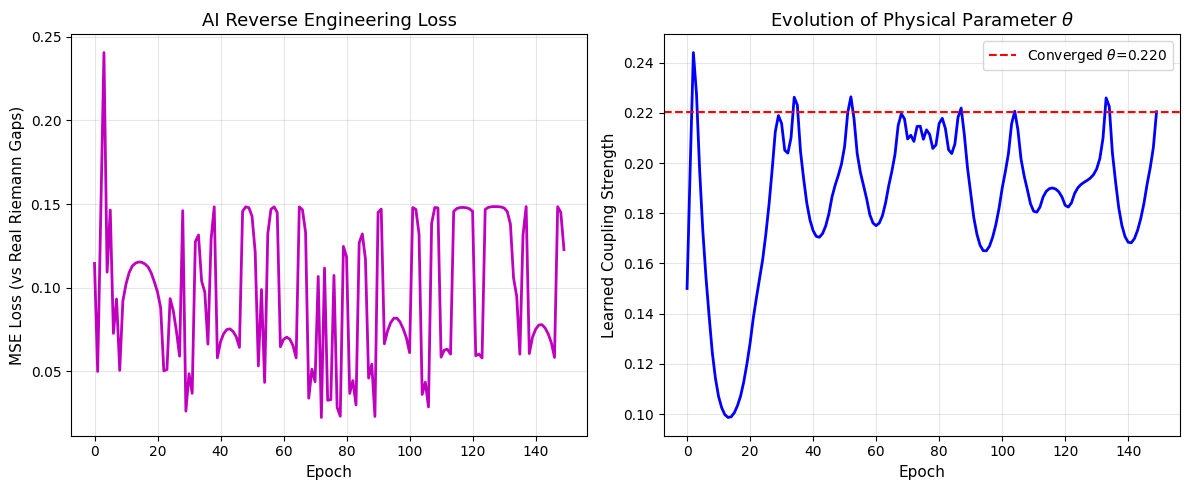

In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# =================================================================
# 1. 准备大自然的 Target (真实的黎曼零点数据)
# =================================================================
# 这是大自然真正的底牌：黎曼 Zeta 函数的前 10 个非平凡零点 (虚部)
riemann_zeros = torch.tensor([
    14.134725, 21.022040, 25.010857, 30.424876, 32.935061, 
    37.586178, 40.918719, 43.327073, 48.005150, 49.773832
], dtype=torch.float32)

# 计算真实的零点间距 (Gaps) 并进行均值归一化 (拉平尺子)
real_gaps = torch.diff(riemann_zeros)
target_gaps = real_gaps / torch.mean(real_gaps)
# 将目标排序，方便我们与矩阵的特征值间距做绝对的 One-to-One 拟合
target_gaps_sorted, _ = torch.sort(target_gaps)

print("大自然的 Target (真实黎曼零点归一化间距) 已锁定：")
print(target_gaps_sorted.detach().numpy())

# =================================================================
# 2. 构建可微的非自治物理宇宙 (Differentiable Physics)
# =================================================================
N = 10  # 维度与我们取样的零点间距数量对齐
torch.manual_seed(42) # 固定种子，保证骨架稳定

# 基础宇宙骨架 (自治部分)
A_base = torch.randn(N, N) + 1j * torch.randn(N, N)
Q_base, _ = torch.linalg.qr(A_base)

# 纯随机的扰动矩阵 (模拟时间的微扰)
V_perturbation = torch.randn(N, N) + 1j * torch.randn(N, N)

# 【核心黑科技】：定义一个可学习的物理参数 theta (代表时间演化的耦合强度)
# 我们把它注册为需要计算梯度的 Parameter
theta = torch.tensor([0.1], requires_grad=True)

# 定义 AI 的优化器 (Adam)，让它专门负责调整 theta
optimizer = optim.Adam([theta], lr=0.05)

# =================================================================
# 3. 开启 AI 炼丹炉：反向传播与法则逼近
# =================================================================
epochs = 150
loss_history = []
theta_history = []

print("\n🚀 启动 AI 逆向工程：开始用真实零点反推时间演化参数...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 步骤 A：正向物理演化 (Forward Physics)
    # 我们用 theta 去混合基础宇宙和时间微扰，构建当前时刻的物理法则
    A_t = Q_base + theta * V_perturbation
    
    # 强制守恒 (可微的 QR 分解)
    Q_t, _ = torch.linalg.qr(A_t)
    
    # 提取特征值 (可微的特征谱)
    eigvals = torch.linalg.eigvals(Q_t)
    
    # 获取相位角，排序，求间距，归一化
    phases = torch.angle(eigvals)
    phases_sorted, _ = torch.sort(phases)
    pred_gaps = torch.diff(phases_sorted)
    pred_gaps_normalized = pred_gaps / torch.mean(pred_gaps)
    pred_gaps_sorted, _ = torch.sort(pred_gaps_normalized)
    
    # 步骤 B：计算代价 (Loss Function)
    # 我们的模型生成的特征值间距，和真实的黎曼零点间距，到底差多少？
    loss = torch.nn.functional.mse_loss(pred_gaps_sorted, target_gaps_sorted)
    
    # 步骤 C：反向传播！大自然的密码开始泄露 (Backward)
    loss.backward()
    optimizer.step() # AI 自动修改 theta，让下一次生成的间距更逼近黎曼零点
    
    loss_history.append(loss.item())
    theta_history.append(theta.item())
    
    if (epoch+1) % 30 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | 探索到的物理参数 theta: {theta.item():.4f}")

# =================================================================
# 4. 可视化：见证 AI 是如何从瞎猜到逼近真理的
# =================================================================
plt.figure(figsize=(12, 5))

# 左图：Loss 下降曲线 (代表 AI 离真理越来越近)
plt.subplot(1, 2, 1)
plt.plot(loss_history, 'm-', lw=2)
plt.title("AI Reverse Engineering Loss", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("MSE Loss (vs Real Riemann Gaps)", fontsize=11)
plt.grid(alpha=0.3)

# 右图：物理参数 theta 的收敛过程
plt.subplot(1, 2, 2)
plt.plot(theta_history, 'b-', lw=2)
plt.axhline(y=theta_history[-1], color='r', linestyle='--', label=f'Converged $\\theta$={theta_history[-1]:.3f}')
plt.title("Evolution of Physical Parameter $\\theta$", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Learned Coupling Strength", fontsize=11)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()